Lets test the signal processing, and how accurate our results are gonna be for a given noise signal. Make sure that ALenv conda env is loaded, yaml file in git repo.

In [283]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

Generate a base sin wave signal at 400Hz

In [288]:
tgrid = np.linspace(0,100,100000)
ygrid1 = np.sin(tgrid*800*np.pi)

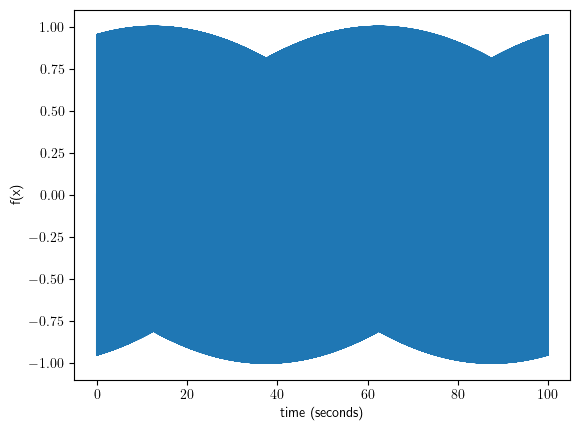

In [293]:
plt.plot(tgrid,ygrid1)
plt.xlabel("time (seconds)")
plt.ylabel("f(x)")
plt.show()

First, we add a second cosine signal of 100Hz. Then, we add noise *only* to the y values, leaving the x vals as a perfect time series.

In [290]:
ygrid = np.zeros(len(ygrid1))
ygrid2 = 3*np.cos(tgrid*200*np.pi)
for i in range(len(ygrid1)):
    ygrid2[i] = ygrid2[i]*np.random.normal(1,0.5)
    ygrid[i] = ygrid1[i]*np.random.normal(1,0.5)

ygrid = ygrid + ygrid2

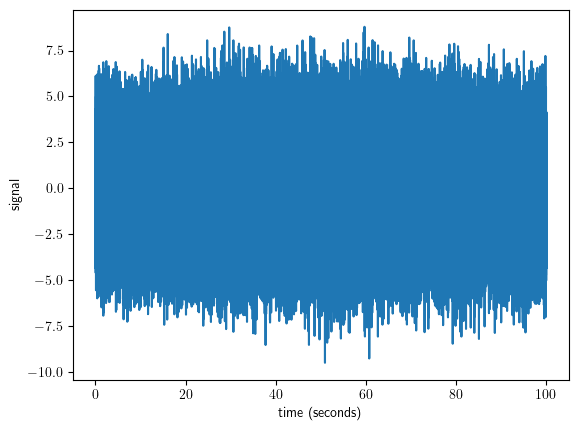

In [292]:
plt.plot(tgrid,ygrid)
plt.xlabel('time (seconds)')
plt.ylabel('signal')
plt.show()

Now, pass y-noise signal through scipy's Welch PSD estimate. We have to provide the sampling frequency, which in our case is 1000Hz. The estimator is going to be limited to 1/2 of this sampling frequency in its output.

In [294]:
tpsd, ypsd = sp.signal.welch(ygrid,fs=1000)

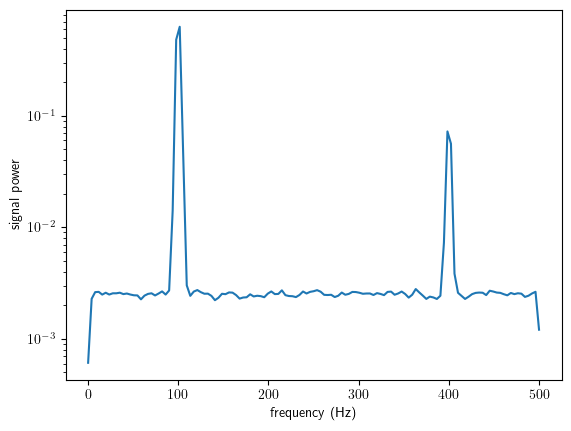

In [374]:
plt.plot(tpsd,ypsd)
plt.semilogy()
plt.xlabel("frequency (Hz)")
plt.ylabel("signal power")
plt.show()

In [375]:
np.trapezoid(ypsd,tpsd)

np.float64(6.268501012487276)

Ok that works, some small noise surrounding two peaks at 100 and 400. We see above that this result isn't normalized, meaning there are some units attached to this thing we have to think about. We could do just fractional signal power if the units get too much of a pain to figure out, still shows dominant signal components.

Now, lets add noise into the x array for inconsistent measurement intervals. We will likely have this type of error in our measurements from delays in getting GPS time, differing times for the Arduino to complete one loop cycle, and potential signal loss over RF.

In [389]:
tgrid2 = np.linspace(0,100,100000)
tgrid3 = np.linspace(0,100,100000)
for i in range(len(tgrid2)):
    tgrid2[i] = tgrid2[i] + np.random.normal(0,0.001)
    tgrid3[i] = tgrid3[i] + np.random.normal(0,0.001)
tgrid2 = np.sort(tgrid2)
tgrid3 = np.sort(tgrid3)

We inject noise into the time series on the order of the sampling frequency, simulating dropped packets or normal delays in processing. Now, we use the same wave patterns as before but with this new t noise.

In [390]:
ygrid3 = np.sin(tgrid2*(800*np.pi))
ygrid4 = 3*np.cos(tgrid3*200*np.pi)
for i in range(len(ygrid3)):
    ygrid3[i] = ygrid3[i]*np.random.normal(1,0.5)
    ygrid4[i] = ygrid4[i]*np.random.normal(1,0.5)
ygrid5 = ygrid3 + ygrid4

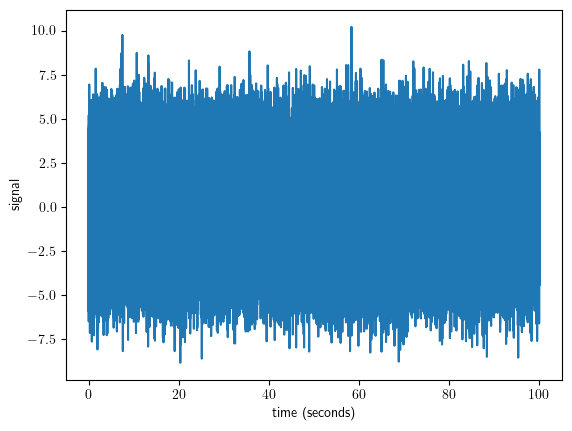

In [391]:
plt.plot(tgrid2,ygrid5)
plt.xlabel('time (seconds)')
plt.ylabel("signal")
plt.show()

time to estimate PSD and plot

In [392]:
tpsd2,ypsd2 = sp.signal.welch(ygrid5,fs=1000)

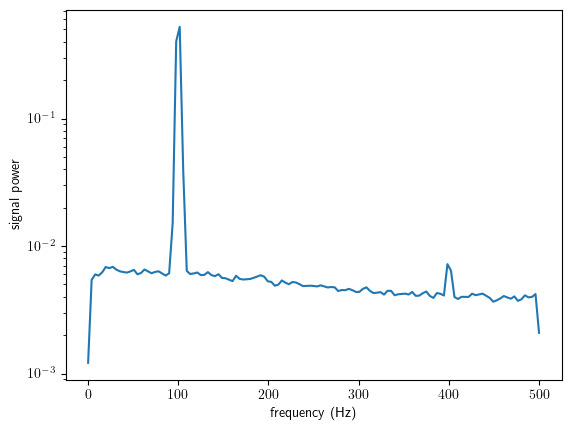

In [393]:
plt.plot(tpsd2,ypsd2)
plt.semilogy()
plt.xlabel('frequency (Hz)')
plt.ylabel('signal power')
plt.show()

with time noise on order of 0.001, we see that the 100Hz signal becomes much more dominant in the PSD than the 400Hz. When we double the time noise to ~ 0.002, the 400Hz signature disappears completely. I expect that this is inherent to signals close to 1/2 the sampling frequency and that we'll have much better luck down in the ~ 10Hz range.